# Post Pandemic Regime Shifts in Labor Market: Structural Benchmark

## Purpose


## Research Context


## Imports and Configuration

In [1]:
%matplotlib inline

from IPython.display import display

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

from pathlib import Path

from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, HuberRegressor, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from regime_shift.config import (
    FIG_ROOT,
    MODEL_ROOT,
    PRICE_MODEL_READY_PATH,
    REPORT_ROOT,
    SAVE_DPI,
    SHOW_DEC,
    WAGE_MODEL_READY_PATH,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

for path in (FIG_ROOT, MODEL_ROOT, REPORT_ROOT):
    Path(path).mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")

## Load Dataset

In [2]:
wage_data = pd.read_csv(WAGE_MODEL_READY_PATH)
price_data = pd.read_csv(PRICE_MODEL_READY_PATH)

for data in [wage_data, price_data]:
    data["date"] = pd.to_datetime(data["date"], errors="coerce")
    data.dropna(subset=["date"], inplace=True)
    data.sort_values("date", inplace=True)
    data.reset_index(drop=True, inplace=True)

## Structural Design


In [3]:
def target_map() -> dict:
    return {
        "wage": [
            "wage_target_3",
            "wage_target_6",
            "wage_target_12",
        ],
        "price": [
            "cpi_target_3",
            "cpi_target_6",
            "cpi_target_12",
            "pce_target_3",
            "pce_target_6",
            "pce_target_12",
        ],
    }

In [4]:
STRUCTURAL_SIGNAL = "log_jolts_ratio"
STRUCTURAL_CONTROLS = ["fed_funds", "hy_oas"]
SIGNAL_COLS = ["log_jolts_ratio", "unemployment_rate", "quits_rate"]

all_targets = target_map()["wage"] + target_map()["price"]

In [5]:
def horizon(target_col: str) -> int:
    return int(target_col.rsplit("_", 1)[-1])

In [6]:
def target_name(target_col: str) -> str:
    root = target_col.replace("_target_", "_")
    if root.startswith("wage"):
        return "Wage"
    if root.startswith("cpi"):
        return "CPI"
    if root.startswith("pce"):
        return "PCE"
    return target_col

In [7]:
def unique_cols(cols: list[str]) -> list[str]:
    seen = set()
    out = []

    for col in cols:
        if col not in seen:
            seen.add(col)
            out.append(col)

    return out

In [8]:
def add_target_lag(data: pd.DataFrame, target_col: str) -> tuple[pd.DataFrame, str]:
    lag_col = f"{target_col}_lag"
    out = data.copy()
    out[lag_col] = out[target_col].shift(horizon(target_col))

    return out, lag_col

In [9]:
def structural_feature_block(
    data: pd.DataFrame,
    target_col: str,
    signal_col: str = STRUCTURAL_SIGNAL,
) -> tuple[pd.DataFrame, list[str], str]:
    out, lag_col = add_target_lag(data, target_col)

    feat_cols = unique_cols(
        [
            signal_col,
            lag_col,
            *STRUCTURAL_CONTROLS,
        ]
    )

    need_cols = unique_cols(
        [
            "date",
            target_col,
            *feat_cols,
            "pre_regime",
            "shock_regime",
            "post_regime",
        ]
    )

    out = out.loc[:, [col for col in need_cols if col in out.columns]].copy()
    out = out.dropna().reset_index(drop=True)

    return out, feat_cols, lag_col

In [10]:
def fetch_signal_data(
    data: pd.DataFrame,
    target_col: str,
    signal_col: str = STRUCTURAL_SIGNAL,
) -> tuple[pd.DataFrame, list[str], str]:
    return structural_feature_block(data, target_col, signal_col=signal_col)

In [11]:
def fetch_data(data: pd.DataFrame, target_col: str) -> pd.DataFrame:
    sample, feat_cols, lag_col = fetch_signal_data(data, target_col)

    keep_cols = unique_cols(
        [
            "date",
            target_col,
            lag_col,
            *feat_cols,
            "pre_regime",
            "shock_regime",
            "post_regime",
        ]
    )

    return sample.loc[:, keep_cols].copy()

In [12]:
target_data = pd.DataFrame(
    {
        "target_col": all_targets,
        "target": [target_name(col) for col in all_targets],
        "horizon": [horizon(col) for col in all_targets],
    }
).sort_values(["target", "horizon"]).reset_index(drop=True)

display(target_data)

,target_col,target,horizon
0,cpi_target_3,CPI,3
1,cpi_target_6,CPI,6
2,cpi_target_12,CPI,12
3,pce_target_3,PCE,3
4,pce_target_6,PCE,6
5,pce_target_12,PCE,12
6,wage_target_3,Wage,3
7,wage_target_6,Wage,6
8,wage_target_12,Wage,12


## Sample Summary


In [13]:
def sample_summary(data: pd.DataFrame, target_col: str) -> pd.DataFrame:
    sample = fetch_data(data, target_col)

    return pd.DataFrame(
        {
            "target": [target_name(target_col)],
            "target_col": [target_col],
            "horizon": [horizon(target_col)],
            "rows": [len(sample)],
            "start": [sample["date"].min()],
            "end": [sample["date"].max()],
            "pre_rows": [int(sample["pre_regime"].sum())],
            "shock_rows": [int(sample["shock_regime"].sum())],
            "post_rows": [int(sample["post_regime"].sum())],
        }
    )

In [14]:
sample_parts = []

for target_col in all_targets:
    base_data = wage_data if target_col.startswith("wage_") else price_data
    sample_parts.append(sample_summary(base_data, target_col))

sample_data = pd.concat(sample_parts, ignore_index=True)
display(sample_data.sort_values(["target", "horizon"]).reset_index(drop=True))

,target,target_col,horizon,rows,start,end,pre_rows,shock_rows,post_rows
0,CPI,cpi_target_3,3,31,2001-05-01,2025-01-01,26,1,4
1,CPI,cpi_target_6,6,48,2001-04-01,2025-08-01,33,3,12
2,CPI,cpi_target_12,12,42,2001-07-01,2024-08-01,35,2,5
3,PCE,pce_target_3,3,31,2001-02-01,2025-06-01,26,3,2
4,PCE,pce_target_6,6,53,2001-06-01,2025-07-01,39,3,11
5,PCE,pce_target_12,12,47,2001-08-01,2024-07-01,37,3,7
6,Wage,wage_target_3,3,109,2006-06-01,2025-09-01,87,6,16
7,Wage,wage_target_6,6,94,2006-07-01,2025-09-01,67,9,18
8,Wage,wage_target_12,12,37,2007-10-01,2024-10-01,22,6,9


## Evaluation Metrics

In [15]:
def root_mean_square_error(actual: np.ndarray, pred: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(actual, pred)))


def mean_absolute_error_value(actual: np.ndarray, pred: np.ndarray) -> float:
    return float(mean_absolute_error(actual, pred))


def out_sample_r_squared(actual: np.ndarray, pred: np.ndarray, base_pred: np.ndarray) -> float:
    model_mse = mean_squared_error(actual, pred)
    base_mse = mean_squared_error(actual, base_pred)

    if base_mse == 0:
        return np.nan

    return float(1.0 - (model_mse / base_mse))


def score_row(
    target_col: str,
    model: str,
    split: str,
    actual: np.ndarray,
    pred: np.ndarray,
    base_pred: np.ndarray,
    train_end: pd.Timestamp,
    test_start: pd.Timestamp,
    test_end: pd.Timestamp,
) -> dict:
    return {
        "target": target_name(target_col),
        "target_col": target_col,
        "horizon": horizon(target_col),
        "model": model,
        "split": split,
        "rmse": root_mean_square_error(actual, pred),
        "mae": mean_absolute_error_value(actual, pred),
        "oos_r2_vs_persistence": out_sample_r_squared(actual, pred, base_pred),
        "row_count": len(actual),
        "train_end": train_end,
        "test_start": test_start,
        "test_end": test_end,
    }

## Model Functions

In [16]:
def fit_persistence(train_target: pd.Series, test_feat: pd.DataFrame) -> np.ndarray:
    last_value = float(train_target.iloc[-1])
    return np.repeat(last_value, len(test_feat))


def fit_ols(train_feat: pd.DataFrame, train_target: pd.Series, test_feat: pd.DataFrame) -> np.ndarray:
    train_data = sm.add_constant(train_feat, has_constant="add")
    test_data = sm.add_constant(test_feat, has_constant="add")
    test_data = test_data.reindex(columns=train_data.columns, fill_value=0.0)

    fit = sm.OLS(train_target, train_data).fit()
    pred = fit.predict(test_data)

    return np.asarray(pred)


def fit_pipe(model, train_feat: pd.DataFrame, train_target: pd.Series, test_feat: pd.DataFrame) -> np.ndarray:
    pipe = Pipeline(
        [
            ("scale", StandardScaler()),
            ("model", clone(model)),
        ]
    )

    pipe.fit(train_feat, train_target)
    pred = pipe.predict(test_feat)

    return np.asarray(pred)


def fit_tree(model, train_feat: pd.DataFrame, train_target: pd.Series, test_feat: pd.DataFrame) -> np.ndarray:
    fit = clone(model)
    fit.fit(train_feat, train_target)
    pred = fit.predict(test_feat)

    return np.asarray(pred)

In [17]:
linear_model_map = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.02, max_iter=20000, random_state=42),
    "ElasticNet": ElasticNet(alpha=0.03, l1_ratio=0.5, max_iter=20000, random_state=42),
    "Huber": HuberRegressor(epsilon=1.35, alpha=0.0001, max_iter=500),
}

In [18]:
tree_model_map = {
    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        max_depth=4,
        min_samples_leaf=5,
        random_state=42,
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.03,
        max_depth=2,
        subsample=0.90,
        random_state=42,
    ),
}

In [19]:
model_names = [
    "Persistence",
    "AR",
    "OLS",
    "Ridge",
    "Lasso",
    "ElasticNet",
    "Huber",
    "RandomForest",
    "GradientBoosting",
]

display(pd.DataFrame({"model": model_names}))

,model
0,Persistence
1,AR
2,OLS
3,Ridge
4,Lasso
5,ElasticNet
6,Huber
7,RandomForest
8,GradientBoosting


## Expanding Forecast


In [20]:
def fold_points(
    data: pd.DataFrame,
    folds: int = 5,
    min_train: int = 60,
) -> list[tuple[slice, slice]]:
    row_count = len(data)

    if row_count <= min_train + 1:
        return []

    test_size = max(1, row_count // (folds + 1))
    points = []
    train_end = min_train

    while train_end + test_size <= row_count and len(points) < folds:
        points.append((slice(0, train_end), slice(train_end, train_end + test_size)))
        train_end += test_size

    return points

In [21]:
def model_pred(
    model: str,
    train_feat: pd.DataFrame,
    train_target: pd.Series,
    test_feat: pd.DataFrame,
    lag_col: str,
) -> np.ndarray:
    if model == "Persistence":
        return fit_persistence(train_target, test_feat)

    if model == "AR":
        return fit_ols(train_feat[[lag_col]], train_target, test_feat[[lag_col]])

    if model == "OLS":
        return fit_ols(train_feat, train_target, test_feat)

    if model in linear_model_map:
        return fit_pipe(linear_model_map[model], train_feat, train_target, test_feat)

    if model in tree_model_map:
        return fit_tree(tree_model_map[model], train_feat, train_target, test_feat)

    raise ValueError(f"Unknown model: {model}")

In [22]:
def pre_post_run(data: pd.DataFrame, target_col: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    sample, feat_cols, lag_col = fetch_signal_data(data, target_col)

    train_data = sample.loc[sample["pre_regime"].eq(1)].copy()
    test_data = sample.loc[sample["post_regime"].eq(1)].copy()

    if train_data.empty or test_data.empty:
        return pd.DataFrame(), pd.DataFrame()

    train_feat = train_data[feat_cols].copy()
    train_target = train_data[target_col].copy()
    test_feat = test_data[feat_cols].copy()
    test_target = test_data[target_col].copy()

    base_pred = fit_persistence(train_target, test_feat)

    score_parts = []
    prediction_parts = []

    for model in model_names:
        pred = model_pred(model, train_feat, train_target, test_feat, lag_col)

        score_parts.append(
            score_row(
                target_col=target_col,
                model=model,
                split="Pre to Post",
                actual=np.asarray(test_target),
                pred=np.asarray(pred),
                base_pred=np.asarray(base_pred),
                train_end=train_data["date"].max(),
                test_start=test_data["date"].min(),
                test_end=test_data["date"].max(),
            )
        )

        prediction_parts.append(
            pd.DataFrame(
                {
                    "date": test_data["date"].values,
                    "actual": np.asarray(test_target),
                    "prediction": np.asarray(pred),
                    "benchmark": np.asarray(base_pred),
                    "model": model,
                    "target": target_name(target_col),
                    "target_col": target_col,
                    "horizon": horizon(target_col),
                    "split": "Pre to Post",
                }
            )
        )

    score_data = pd.DataFrame(score_parts)
    prediction_data = pd.concat(prediction_parts, ignore_index=True)

    return score_data, prediction_data

In [23]:
def window_run(
    data: pd.DataFrame,
    target_cols: list[str],
    folds: int = 5,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    score_parts = []
    prediction_parts = []

    for target_col in target_cols:
        sample, feat_cols, lag_col = fetch_signal_data(data, target_col)

        points = fold_points(
            sample,
            folds=folds,
            min_train=max(48, horizon(target_col) * 8),
        )

        for train_slice, test_slice in points:
            train_data = sample.iloc[train_slice].copy()
            test_data = sample.iloc[test_slice].copy()

            if train_data.empty or test_data.empty:
                continue

            train_feat = train_data[feat_cols].copy()
            train_target = train_data[target_col].copy()
            test_feat = test_data[feat_cols].copy()
            test_target = test_data[target_col].copy()

            base_pred = fit_persistence(train_target, test_feat)

            for model in model_names:
                pred = model_pred(model, train_feat, train_target, test_feat, lag_col)

                score_parts.append(
                    score_row(
                        target_col=target_col,
                        model=model,
                        split="Expanding Window",
                        actual=np.asarray(test_target),
                        pred=np.asarray(pred),
                        base_pred=np.asarray(base_pred),
                        train_end=train_data["date"].max(),
                        test_start=test_data["date"].min(),
                        test_end=test_data["date"].max(),
                    )
                )

                prediction_parts.append(
                    pd.DataFrame(
                        {
                            "date": test_data["date"].values,
                            "actual": np.asarray(test_target),
                            "prediction": np.asarray(pred),
                            "benchmark": np.asarray(base_pred),
                            "model": model,
                            "target": target_name(target_col),
                            "target_col": target_col,
                            "horizon": horizon(target_col),
                            "split": "Expanding Window",
                        }
                    )
                )

    score_data = pd.DataFrame(score_parts)
    prediction_data = pd.concat(prediction_parts, ignore_index=True) if prediction_parts else pd.DataFrame()

    return score_data, prediction_data

In [24]:
split_score_parts = []
split_prediction_parts = []

for target_col in all_targets:
    base_data = wage_data if target_col.startswith("wage_") else price_data
    score_data, prediction_data = pre_post_run(base_data, target_col)

    if not score_data.empty:
        split_score_parts.append(score_data)

    if not prediction_data.empty:
        split_prediction_parts.append(prediction_data)

split_scores = pd.concat(split_score_parts, ignore_index=True) if split_score_parts else pd.DataFrame()
split_predictions = pd.concat(split_prediction_parts, ignore_index=True) if split_prediction_parts else pd.DataFrame()

In [25]:
window_wage_scores, window_wage_predictions = window_run(wage_data, target_map()["wage"])
window_price_scores, window_price_predictions = window_run(price_data, target_map()["price"])

window_scores = pd.concat(
    [
        window_wage_scores,
        window_price_scores,
    ],
    ignore_index=True,
) if (not window_wage_scores.empty or not window_price_scores.empty) else pd.DataFrame()

window_predictions = pd.concat(
    [
        window_wage_predictions,
        window_price_predictions,
    ],
    ignore_index=True,
) if (not window_wage_predictions.empty or not window_price_predictions.empty) else pd.DataFrame()

In [26]:
display(split_scores.sort_values(["target", "horizon", "rmse", "mae"]).reset_index(drop=True).round(SHOW_DEC))
display(window_scores.sort_values(["target", "horizon", "rmse", "mae"]).reset_index(drop=True).round(SHOW_DEC))

,target,target_col,horizon,model,split,rmse,mae,oos_r2_vs_persistence,row_count,train_end,test_start,test_end
0,CPI,cpi_target_3,3,AR,Pre to Post,2.2018,1.8190,0.8758,4,2019-12-01,2021-12-01,2025-01-01
1,CPI,cpi_target_3,3,Huber,Pre to Post,2.6782,2.1103,0.8163,4,2019-12-01,2021-12-01,2025-01-01
2,CPI,cpi_target_3,3,Lasso,Pre to Post,3.0534,2.3757,0.7612,4,2019-12-01,2021-12-01,2025-01-01
3,CPI,cpi_target_3,3,ElasticNet,Pre to Post,3.0762,2.3870,0.7577,4,2019-12-01,2021-12-01,2025-01-01
4,CPI,cpi_target_3,3,OLS,Pre to Post,3.0814,2.3870,0.7568,4,2019-12-01,2021-12-01,2025-01-01
5,CPI,cpi_target_3,3,Ridge,Pre to Post,3.1185,2.4069,0.7509,4,2019-12-01,2021-12-01,2025-01-01
6,CPI,cpi_target_3,3,RandomForest,Pre to Post,3.3783,2.3149,0.7077,4,2019-12-01,2021-12-01,2025-01-01
7,CPI,cpi_target_3,3,GradientBoosting,Pre to Post,3.4913,2.2491,0.6879,4,2019-12-01,2021-12-01,2025-01-01
8,CPI,cpi_target_3,3,Persistence,Pre to Post,6.2489,5.4923,0.0000,4,2019-12-01,2021-12-01,2025-01-01
9,CPI,cpi_target_6,6,AR,Pre to Post,0.3039,0.2510,0.9953,12,2019-12-01,2021-06-01,2025-08-01


,target,target_col,horizon,model,split,rmse,mae,oos_r2_vs_persistence,row_count,train_end,test_start,test_end
0,Wage,wage_target_3,3,GradientBoosting,Expanding Window,0.4567,0.3564,0.5798,18,2015-08-01,2015-09-01,2018-10-01
1,Wage,wage_target_3,3,OLS,Expanding Window,0.4675,0.3640,0.5596,18,2015-08-01,2015-09-01,2018-10-01
2,Wage,wage_target_3,3,Ridge,Expanding Window,0.4678,0.3646,0.5590,18,2015-08-01,2015-09-01,2018-10-01
3,Wage,wage_target_3,3,GradientBoosting,Expanding Window,0.4707,0.3707,0.4922,18,2012-09-01,2012-10-01,2015-08-01
4,Wage,wage_target_3,3,ElasticNet,Expanding Window,0.4865,0.3770,0.5231,18,2015-08-01,2015-09-01,2018-10-01
5,Wage,wage_target_3,3,RandomForest,Expanding Window,0.4868,0.3534,0.5224,18,2015-08-01,2015-09-01,2018-10-01
6,Wage,wage_target_3,3,Lasso,Expanding Window,0.4942,0.3814,0.5079,18,2015-08-01,2015-09-01,2018-10-01
7,Wage,wage_target_3,3,Huber,Expanding Window,0.5030,0.4145,0.4201,18,2012-09-01,2012-10-01,2015-08-01
8,Wage,wage_target_3,3,Ridge,Expanding Window,0.5058,0.4162,0.4136,18,2012-09-01,2012-10-01,2015-08-01
9,Wage,wage_target_3,3,OLS,Expanding Window,0.5125,0.4242,0.3981,18,2012-09-01,2012-10-01,2015-08-01


## Forecast Comparison Summary

In [27]:
all_scores = pd.concat(
    [
        split_scores,
        window_scores,
    ],
    ignore_index=True,
) if (not split_scores.empty or not window_scores.empty) else pd.DataFrame()

In [28]:
score_summary = (
    all_scores.groupby(
        ["target", "target_col", "horizon", "model", "split"],
        as_index=False,
    )
    .agg(
        rmse=("rmse", "mean"),
        mae=("mae", "mean"),
        oos_r2=("oos_r2_vs_persistence", "mean"),
        row_count=("row_count", "sum"),
    )
    .sort_values(["split", "target", "horizon", "rmse", "mae"])
    .reset_index(drop=True)
)

display(score_summary.round(SHOW_DEC))

,target,target_col,horizon,model,split,rmse,mae,oos_r2,row_count
0,Wage,wage_target_3,3,Ridge,Expanding Window,0.7923,0.6260,0.3833,54
1,Wage,wage_target_3,3,OLS,Expanding Window,0.7941,0.6284,0.3787,54
2,Wage,wage_target_3,3,ElasticNet,Expanding Window,0.8038,0.6360,0.3613,54
3,Wage,wage_target_3,3,Lasso,Expanding Window,0.8097,0.6416,0.3482,54
4,Wage,wage_target_3,3,Huber,Expanding Window,0.8309,0.6547,0.3177,54
5,Wage,wage_target_3,3,AR,Expanding Window,0.8446,0.6783,0.2600,54
6,Wage,wage_target_3,3,GradientBoosting,Expanding Window,0.9525,0.7356,0.1717,54
7,Wage,wage_target_3,3,Persistence,Expanding Window,0.9707,0.7970,0.0000,54
8,Wage,wage_target_3,3,RandomForest,Expanding Window,1.0266,0.7898,0.0274,54
9,Wage,wage_target_6,6,OLS,Expanding Window,0.9270,0.6992,0.7031,45


In [29]:
rank_summary = score_summary.copy()

rank_summary["rmse_rank"] = rank_summary.groupby(["split", "target_col"])["rmse"].rank(method="dense")
rank_summary["mae_rank"] = rank_summary.groupby(["split", "target_col"])["mae"].rank(method="dense")
rank_summary["avg_rank"] = (rank_summary["rmse_rank"] + rank_summary["mae_rank"]) / 2.0

In [30]:
best_summary = (
    rank_summary.sort_values(["split", "target_col", "avg_rank", "rmse", "mae"])
    .groupby(["split", "target_col"], as_index=False)
    .first()
    .sort_values(["split", "target", "horizon"])
    .reset_index(drop=True)
)

display(best_summary.round(SHOW_DEC))

,split,target_col,target,horizon,model,rmse,mae,oos_r2,row_count,rmse_rank,mae_rank,avg_rank
0,Expanding Window,wage_target_3,Wage,3,Ridge,0.7923,0.6260,0.3833,54,1.0000,1.0000,1.0000
1,Expanding Window,wage_target_6,Wage,6,OLS,0.9270,0.6992,0.7031,45,1.0000,2.0000,1.5000
2,Pre to Post,cpi_target_3,CPI,3,AR,2.2018,1.8190,0.8758,4,1.0000,1.0000,1.0000
3,Pre to Post,cpi_target_6,CPI,6,AR,0.3039,0.2510,0.9953,12,1.0000,1.0000,1.0000
4,Pre to Post,cpi_target_12,CPI,12,OLS,0.3489,0.2765,0.9800,5,1.0000,1.0000,1.0000
5,Pre to Post,pce_target_3,PCE,3,Huber,0.3518,0.2995,0.4441,2,1.0000,1.0000,1.0000
6,Pre to Post,pce_target_6,PCE,6,Ridge,0.5339,0.3531,0.9637,11,2.0000,2.0000,2.0000
7,Pre to Post,pce_target_12,PCE,12,AR,0.5420,0.4355,0.9770,7,1.0000,1.0000,1.0000
8,Pre to Post,wage_target_3,Wage,3,OLS,0.7796,0.6357,0.7144,16,1.0000,1.0000,1.0000
9,Pre to Post,wage_target_6,Wage,6,ElasticNet,0.3576,0.2828,0.9954,18,1.0000,1.0000,1.0000


In [31]:
core_summary = score_summary.loc[
    score_summary["model"].isin(["AR", "OLS", "Ridge", "ElasticNet", "Huber"])
].copy()

In [32]:
ar_summary = core_summary.loc[core_summary["model"].eq("AR")].copy()
ar_summary = ar_summary.rename(
    columns={
        "rmse": "ar_rmse",
        "mae": "ar_mae",
        "oos_r2": "ar_oos_r2",
    }
)[["target_col", "split", "ar_rmse", "ar_mae", "ar_oos_r2"]]

In [33]:
best_core = (
    core_summary.sort_values(["split", "target_col", "rmse", "mae"])
    .groupby(["split", "target_col"], as_index=False)
    .first()
    .sort_values(["split", "target", "horizon"])
    .reset_index(drop=True)
)

In [34]:
gain_summary = best_core.merge(ar_summary, on=["target_col", "split"], how="left")
gain_summary["rmse_gain_vs_ar"] = gain_summary["ar_rmse"] - gain_summary["rmse"]
gain_summary["mae_gain_vs_ar"] = gain_summary["ar_mae"] - gain_summary["mae"]

display(
    gain_summary[
        [
            "target",
            "target_col",
            "horizon",
            "split",
            "model",
            "rmse",
            "mae",
            "oos_r2",
            "ar_rmse",
            "ar_mae",
            "rmse_gain_vs_ar",
            "mae_gain_vs_ar",
        ]
    ].round(SHOW_DEC)
)

,target,target_col,horizon,split,model,rmse,mae,oos_r2,ar_rmse,ar_mae,rmse_gain_vs_ar,mae_gain_vs_ar
0,Wage,wage_target_3,3,Expanding Window,Ridge,0.7923,0.6260,0.3833,0.8446,0.6783,0.0523,0.0523
1,Wage,wage_target_6,6,Expanding Window,OLS,0.9270,0.6992,0.7031,1.0266,0.6894,0.0996,-0.0099
2,CPI,cpi_target_3,3,Pre to Post,AR,2.2018,1.8190,0.8758,2.2018,1.8190,0.0000,0.0000
3,CPI,cpi_target_6,6,Pre to Post,AR,0.3039,0.2510,0.9953,0.3039,0.2510,0.0000,0.0000
4,CPI,cpi_target_12,12,Pre to Post,OLS,0.3489,0.2765,0.9800,0.6370,0.5573,0.2881,0.2808
5,PCE,pce_target_3,3,Pre to Post,Huber,0.3518,0.2995,0.4441,0.6239,0.4467,0.2721,0.1472
6,PCE,pce_target_6,6,Pre to Post,OLS,0.4829,0.3600,0.9703,0.5643,0.3663,0.0814,0.0063
7,PCE,pce_target_12,12,Pre to Post,AR,0.5420,0.4355,0.9770,0.5420,0.4355,0.0000,0.0000
8,Wage,wage_target_3,3,Pre to Post,OLS,0.7796,0.6357,0.7144,1.0141,0.9063,0.2345,0.2705
9,Wage,wage_target_6,6,Pre to Post,ElasticNet,0.3576,0.2828,0.9954,0.4318,0.3144,0.0743,0.0317


## Visualization of Structures

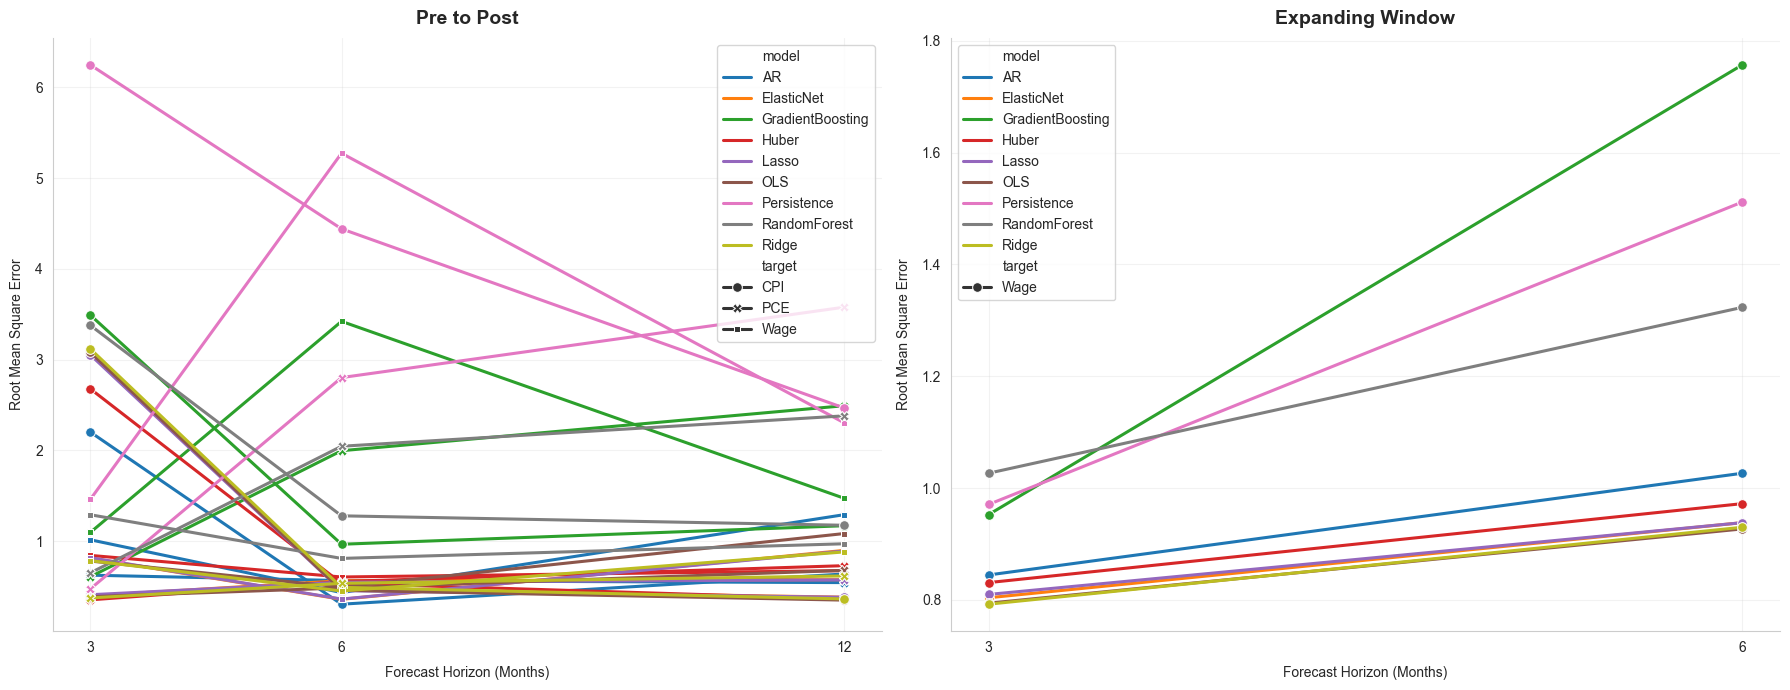

In [35]:
forecast_plot_data = score_summary.copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

for ax, split_name in zip(axes, ["Pre to Post", "Expanding Window"]):
    split_data = forecast_plot_data.loc[forecast_plot_data["split"].eq(split_name)].copy()

    if split_data.empty:
        ax.set_axis_off()
        continue

    split_data = split_data.sort_values(["target", "model", "horizon"])

    sns.lineplot(
        data=split_data,
        x="horizon",
        y="rmse",
        hue="model",
        style="target",
        markers=True,
        dashes=False,
        linewidth=2.2,
        markersize=7,
        ax=ax,
    )

    ax.set_title(split_name, pad=10, fontsize=14, weight="bold")
    ax.set_xlabel("Forecast Horizon (Months)", labelpad=8)
    ax.set_ylabel("Root Mean Square Error", labelpad=8)
    ax.set_xticks(sorted(split_data["horizon"].unique()))
    ax.grid(True, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(FIG_ROOT / "05_forecast_benchmark_errors.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

In [36]:
score_summary.to_csv(REPORT_ROOT / "05_forecast_benchmark_summary.csv", index=False)
best_summary.to_csv(REPORT_ROOT / "05_forecast_benchmark_best_models.csv", index=False)
gain_summary.to_csv(REPORT_ROOT / "05_forecast_benchmark_gain_vs_ar.csv", index=False)

split_scores.to_csv(REPORT_ROOT / "05_forecast_benchmark_pre_post_scores.csv", index=False)
window_scores.to_csv(REPORT_ROOT / "05_forecast_benchmark_window_scores.csv", index=False)

split_predictions.to_csv(MODEL_ROOT / "05_forecast_benchmark_pre_post_predictions.csv", index=False)
window_predictions.to_csv(MODEL_ROOT / "05_forecast_benchmark_window_predictions.csv", index=False)